# 05 - GAT attention analysis (crc_210)

Extends `02_microenv_gat.ipynb`. Loads that notebook's trained CellinaGCN checkpoint and its
microenvironment labels, pulls the learned GATv2 attention coefficients out with
`CellinaGCN.get_attention_weights()`, sanity-checks them, and asks **which cell types a given
cell type attends to** - separately per microenvironment.

**Statistic.** Attention rows sum to 1, so each destination cell splits its incoming attention
across the 9 `coarse_type` categories:

- `mass_i(T)`  = sum of alpha over cell *i*'s in-neighbours of type *T*  (sums to 1 over T)
- `expct_i(T)` = fraction of cell *i*'s in-neighbours that are type *T*  (= mass under uniform attention)
- `enrichment(S, T, M) = log2( mean_i mass_i(T) / mean_i expct_i(T) )` over destination cells *i*
  of type *S* in microenvironment *M*

Raw mass mostly re-derives local composition; the enrichment isolates what attention adds on top
of proximity. **log2 = 0 means "exactly what being nearby predicts"** - that is the reference
point, so no permutation null is computed.

Edges are assigned by **destination** cell and all in-edges are kept regardless of the source's
microenvironment; the boundary-edge fraction is reported so the cross-talk stays visible.

In [1]:
import os
import sys
import json
import time

import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch

SCRIPTS = "/data/ddimitrov/repos/cellina-reproducibility/scripts"
sys.path.append(SCRIPTS)
from utils import set_seed
from train_loo import preprocess_crc

import cellina
from cellina import CellinaGCN
from cellina._spatial_utils import spatial_neighbors

plt.rcParams["font.family"] = "monospace"
plt.rcParams["font.size"] = 11
plt.rcParams["figure.dpi"] = 90

print("cellina", cellina.__version__)
print("torch", torch.__version__, "| cuda", torch.cuda.is_available())

cellina 0.99.1
torch 2.4.1 | cuda True


In [2]:
# ---------------- config (mirrors 02) ----------------
SLIDE_ID  = "crc_210"
DATA_PATH = f"/data/a330d/datasets/crc/raw_zenodo/{SLIDE_ID}.h5ad"

LABELS_KEY, DOMAINS_KEY, BATCH_KEY = "coarse_type", "typ_clean", "sid"

GRAPH_K   = 20
BANDWIDTH = 100 / 0.12028
N_LATENT, N_LAYERS = 64, 2
NUM_NEIGHBORS = [GRAPH_K] * N_LAYERS
CONV_TYPE, SUBGRAPH_TYPE = "gat", "induced"
SEED = 1337

MODEL_DIR = f"./{SLIDE_ID}_gat"
RES_DIR   = f"../results/analysis/{SLIDE_ID}_gat"
ME_PATH   = f"{RES_DIR}/microenvironment_labels_full.csv"

# ---------------- 05-specific ----------------
ATT_BATCH  = 256            # seeds per batch; [-1,-1] fanout expands ~1+20+400 nodes per seed
ATT_CACHE  = {i: f"{RES_DIR}/attention_l{i}.npz" for i in range(N_LAYERS)}
REEXTRACT  = False          # True forces re-extraction even if the cache exists
MIN_DST    = 200            # grey out (dst type x microenv) cells with fewer destination cells
UNIF_GATE  = 0.95           # median entropy ratio above this => attention ~ uniform
DIST_BINS  = 25
ME_ORDER   = ["CRC1", "CRC2", "CRC3", "210_REF", "210_TVA"]

os.makedirs(RES_DIR, exist_ok=True)
set_seed(SEED)

summary = {}
print(json.dumps({"ATT_BATCH": ATT_BATCH, "MIN_DST": MIN_DST, "REEXTRACT": REEXTRACT}, indent=2))

{
  "ATT_BATCH": 256,
  "MIN_DST": 200,
  "REEXTRACT": false
}


## 1. Rebuild the adata exactly as 02 did

The slim `output/crc_210_gat_microenv.h5ad` has **no `X`**, and `get_attention_weights` needs the registered training object (passing a different AnnData is not honoured - the loader is always rebuilt from the registered data). So the adata is regenerated deterministically.

In [3]:
t0 = time.time()
adata = sc.read(DATA_PATH)
adata = preprocess_crc(adata)

# same guard as 02: preprocess_crc filters NaN on `typ`, the model uses `typ_clean`
n_bad = int(adata.obs[DOMAINS_KEY].isna().sum())
if n_bad:
    adata = adata[~adata.obs[DOMAINS_KEY].isna()].copy()
adata.obs[DOMAINS_KEY] = adata.obs[DOMAINS_KEY].astype("category")

spatial_neighbors(adata, bandwidth=BANDWIDTH, max_neighbours=GRAPH_K, standardize=False)
print(f"adata + graph in {(time.time()-t0)/60:.1f} min")
print(adata)

summary["n_cells"], summary["n_genes"] = int(adata.n_obs), int(adata.n_vars)
assert adata.n_obs == 552241, f"cell count drifted from 02: {adata.n_obs}"

/data/ddimitrov/repos/cellina-reproducibility/scripts/train_loo.py:179: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[labels_key] = adata.obs[labels_key].astype("category")


adata + graph in 0.7 min
AnnData object with n_obs × n_vars = 552241 × 2000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_

### Graph orientation - read this before interpreting anything

`spatial_neighbors` builds a **kNN graph, which is not symmetric**: every cell lists its
`GRAPH_K` nearest neighbours (row degree = 20), but a cell can appear in *more* than 20 other
cells' lists (column degree is unbounded).

The loader maps a nonzero `spatial_connectivities[i, j]` to the message `i -> j`, so cell *j*
attends over cell *i*. **A cell's in-neighbours are therefore the cells that list it among their
20 nearest - not its own 20 nearest.** In-degree is what matters here, and the attention matrix
pattern is a subset of `spatial_connectivities.T`.

out-degree: mean 20.00  max 20
in-degree : mean 20.00  max 39  zero-in 20


symmetric: False


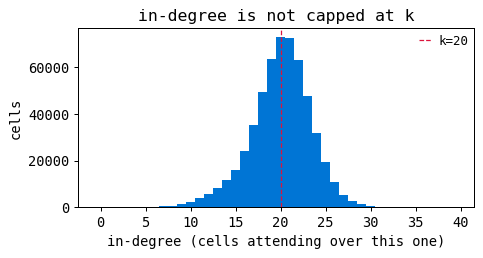

In [4]:
A_conn = adata.obsp["spatial_connectivities"]
out_deg = np.asarray((A_conn > 0).sum(axis=1)).ravel()   # each cell's own kNN list
in_deg  = np.asarray((A_conn > 0).sum(axis=0)).ravel()   # cells that list this one

print(f"out-degree: mean {out_deg.mean():.2f}  max {out_deg.max()}")
print(f"in-degree : mean {in_deg.mean():.2f}  max {in_deg.max()}  "
      f"zero-in {int((in_deg==0).sum())}")
sym = (abs(A_conn - A_conn.T) > 0).nnz == 0
print("symmetric:", sym)

summary["out_degree_max"] = int(out_deg.max())
summary["in_degree_max"] = int(in_deg.max())
summary["n_zero_in_degree"] = int((in_deg == 0).sum())
summary["graph_symmetric"] = bool(sym)

fig, ax = plt.subplots(figsize=(5.5, 3))
ax.hist(in_deg, bins=np.arange(in_deg.max() + 2) - 0.5, color="#0075D5")
ax.axvline(GRAPH_K, color="crimson", ls="--", lw=1, label=f"k={GRAPH_K}")
ax.set_xlabel("in-degree (cells attending over this one)")
ax.set_ylabel("cells"); ax.legend(); ax.set_title("in-degree is not capped at k")
plt.tight_layout(); plt.show()

## 2. Attach the microenvironment labels from 02

In [5]:
me = pd.read_csv(ME_PATH, index_col=0)["microenvironment"]
missing = adata.obs_names.difference(me.index)
assert len(missing) == 0, f"{len(missing)} cells have no microenvironment label"
adata.obs["microenvironment"] = pd.Categorical(me.reindex(adata.obs_names).values)

print(adata.obs["microenvironment"].value_counts())
print()
print(pd.crosstab(adata.obs["microenvironment"], adata.obs[LABELS_KEY]))

CELL_TYPES = list(adata.obs[LABELS_KEY].cat.categories)
ME_PRESENT = [m for m in ME_ORDER if m in set(adata.obs["microenvironment"])]
print("\ncell types:", CELL_TYPES)
print("microenvironments:", ME_PRESENT)

microenvironment
210_TVA    185092
CRC2       137339
CRC3       106419
CRC1        87630
210_REF     35761
Name: count, dtype: int64

coarse_type       B_cell  Endothelial  Epithelial  Fibroblast  Mast_cell  \
microenvironment                                                           
210_REF             2264          817       20274        2456        306   
210_TVA             3047         2207      150841        4550        449   
CRC1                1728         3508       37830       26276        281   
CRC2                3398         3806       90885        8709        324   
CRC3                2549         2743       77177        6544        238   

coarse_type       Myeloid  Plasma_cell  Smooth_muscle  T_cell  
microenvironment                                               
210_REF              1514         4817           1453    1860  
210_TVA              7904         7654           3016    5424  
CRC1                 8850         3724           3579    1854  
CRC2         

## 3. Load the trained model from 02

In [6]:
CellinaGCN.setup_anndata(
    adata,
    batch_key=BATCH_KEY,
    labels_key=LABELS_KEY,
    domains_key=DOMAINS_KEY,
    layer="counts",
    spatial_connectivities_key="spatial_connectivities",
)

ckpt = sorted(os.listdir(MODEL_DIR))[0]
print("loading:", ckpt)
model = CellinaGCN.load(f"{MODEL_DIR}/{ckpt}", adata=adata)
print("convolution_type:", model.module.s_encoder.encoder.convolution_type)
print("condition_on_intrinsic:", model.module.condition_on_intrinsic,
      "-> give_mean is moot; extraction is deterministic either way")

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
INFO: Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


2026-07-27 20:59:56 | [INFO] Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


loading: epoch=19-step=8322-vae_loss_validation=306.0075378417969
INFO     File ./crc_210_gat/epoch=19-step=8322-vae_loss_validation=306.0075378417969/model.pt already downloaded   


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = to

INFO     cellina: The CellinaGCN model has been initialized with adversarial domain forgetting with edge prediction


convolution_type: gat
condition_on_intrinsic: False -> give_mean is moot; extraction is deterministic either way


## 4. Extract attention

`num_neighbors` defaults to `[-1, -1]` (full neighbourhood), which is what makes the coefficients
*exact* rather than a softmax over a sampled subset. Cached to disk, since re-running the
aggregation should not cost another extraction.

In [7]:
have_cache = all(os.path.exists(p) for p in ATT_CACHE.values())

if have_cache and not REEXTRACT:
    att = {i: sp.load_npz(p).tocsr() for i, p in ATT_CACHE.items()}
    print("loaded cached attention:", {i: m.nnz for i, m in att.items()})
else:
    torch.cuda.reset_peak_memory_stats()
    t0 = time.time()
    att = model.get_attention_weights(batch_size=ATT_BATCH)
    mins = (time.time() - t0) / 60
    vram = torch.cuda.max_memory_allocated() / 1e9
    print(f"extracted in {mins:.1f} min | peak VRAM {vram:.2f} GB")
    summary["extract_minutes"] = round(mins, 1)
    summary["extract_peak_vram_gb"] = round(vram, 2)
    for i, m in att.items():
        sp.save_npz(ATT_CACHE[i], m.tocoo())
    print("cached to", RES_DIR)

for i, m in att.items():
    print(f"layer {i}: shape {m.shape}  nnz {m.nnz:,}  dtype {m.dtype}")
summary["attention_nnz"] = {str(i): int(m.nnz) for i, m in att.items()}

extracted in 0.3 min | peak VRAM 0.09 GB


cached to ../results/analysis/crc_210_gat
layer 0: shape (552241, 552241)  nnz 11,044,820  dtype float32
layer 1: shape (552241, 552241)  nnz 11,044,820  dtype float32


In [8]:
# structural invariants (cheap; the extraction should already guarantee these)
for i, m in att.items():
    rs = np.asarray(m.sum(axis=1)).ravel()
    nz = in_deg > 0
    assert np.isfinite(m.data).all(), f"layer {i}: non-finite alpha"
    np.testing.assert_allclose(rs[nz], 1.0, rtol=1e-4, atol=1e-4)
    np.testing.assert_allclose(rs[~nz], 0.0, atol=1e-8)
    outside = (m != 0) - (m != 0).multiply(A_conn.T != 0)
    assert outside.nnz == 0, f"layer {i}: {outside.nnz} entries outside conn.T"
print("row sums = 1 on all cells with in-neighbours; zero rows for the rest")
print("sparsity pattern is a subset of spatial_connectivities.T")

row sums = 1 on all cells with in-neighbours; zero rows for the rest
sparsity pattern is a subset of spatial_connectivities.T


## 5. Sanity check A - is the attention actually non-uniform?

If the GAT converged to near-uniform weights, every enrichment below is noise around zero. Per
destination cell, Shannon entropy of its attention row divided by `log(in-degree)`, which is the
maximum attainable and is reached exactly when attention is uniform.

**Reported, not blocking** - the aggregation runs either way.

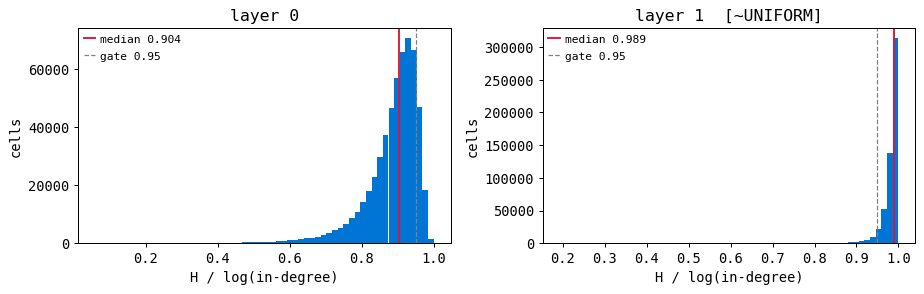

layer 0: median entropy ratio 0.904 -> non-uniform - attention is doing something
layer 1: median entropy ratio 0.989 -> NEAR-UNIFORM - enrichments below are close to meaningless


In [9]:
def row_entropy_ratio(m, deg):
    """H_i / log(deg_i) per row; NaN where deg < 2."""
    m = m.tocsr()
    d = m.data.astype(np.float64)
    with np.errstate(divide="ignore", invalid="ignore"):
        contrib = np.where(d > 0, -d * np.log(d), 0.0)
    H = np.add.reduceat(contrib, m.indptr[:-1]) if m.nnz else np.zeros(m.shape[0])
    H[np.diff(m.indptr) == 0] = 0.0
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = H / np.log(deg)
    ratio[deg < 2] = np.nan
    return ratio, H

fig, axes = plt.subplots(1, N_LAYERS, figsize=(5.2 * N_LAYERS, 3.4), squeeze=False)
for i, m in att.items():
    ratio, _ = row_entropy_ratio(m, in_deg.astype(float))
    med = float(np.nanmedian(ratio))
    summary[f"entropy_ratio_median_l{i}"] = round(med, 4)
    summary[f"uniform_like_l{i}"] = bool(med > UNIF_GATE)

    ax = axes[0, i]
    ax.hist(ratio[np.isfinite(ratio)], bins=60, color="#0075D5")
    ax.axvline(med, color="crimson", lw=1.5, label=f"median {med:.3f}")
    ax.axvline(UNIF_GATE, color="grey", ls="--", lw=1, label=f"gate {UNIF_GATE}")
    ax.set_xlabel("H / log(in-degree)"); ax.set_ylabel("cells")
    ax.set_title(f"layer {i}" + ("  [~UNIFORM]" if med > UNIF_GATE else ""))
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

for i in att:
    med = summary[f"entropy_ratio_median_l{i}"]
    verdict = ("NEAR-UNIFORM - enrichments below are close to meaningless"
               if med > UNIF_GATE else "non-uniform - attention is doing something")
    print(f"layer {i}: median entropy ratio {med:.3f} -> {verdict}")

## 6. Sanity check B - does attention depend on physical distance?

The graph was built with a bandwidth kernel, so some decay is expected. A flat or inverted curve would say the attention is not spatially sensible.

11,044,820 edges | distance median 123.3  p99 264.7


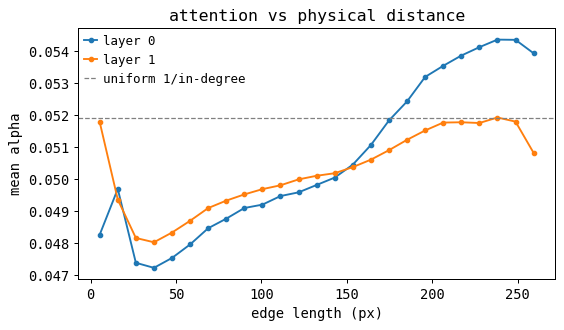

In [10]:
xy = adata.obsm["spatial"]
coo0 = att[0].tocoo()
dst, src = coo0.row, coo0.col
d = np.linalg.norm(xy[dst] - xy[src], axis=1)
print(f"{len(d):,} edges | distance median {np.median(d):.1f}  p99 {np.percentile(d, 99):.1f}")

hi = np.percentile(d, 99)
bins = np.linspace(0, hi, DIST_BINS + 1)
idx = np.clip(np.digitize(d, bins) - 1, 0, DIST_BINS - 1)
ctr = 0.5 * (bins[:-1] + bins[1:])

fig, ax = plt.subplots(figsize=(6.4, 3.8))
for i, m in att.items():
    a = m.tocoo().data.astype(np.float64)
    means = np.bincount(idx, weights=a, minlength=DIST_BINS) / np.maximum(
        np.bincount(idx, minlength=DIST_BINS), 1)
    ax.plot(ctr, means, marker="o", ms=3.5, label=f"layer {i}")
# uniform reference: mean alpha if every in-neighbour weighted equally
ax.axhline(float(np.mean(1.0 / in_deg[in_deg > 0])), color="grey", ls="--", lw=1,
           label="uniform 1/in-degree")
ax.set_xlabel("edge length (px)"); ax.set_ylabel("mean alpha")
ax.set_title("attention vs physical distance"); ax.legend()
plt.tight_layout(); plt.show()

summary["edge_dist_median"] = round(float(np.median(d)), 2)

## 7. Aggregate incoming attention by cell type

`mass = A @ Y` and `counts = pattern(A) @ Y`, where `Y` one-hot encodes `coarse_type`. Building
`expct` from the attention matrix's **own** sparsity pattern guarantees the observed and expected
neighbourhoods are the same set of edges.

In [11]:
codes = adata.obs[LABELS_KEY].cat.codes.values
Y = sp.csr_matrix(
    (np.ones(adata.n_obs, np.float64), (np.arange(adata.n_obs), codes)),
    shape=(adata.n_obs, len(CELL_TYPES)),
)

me_vals = adata.obs["microenvironment"].astype(str).values
dst_type = np.asarray(CELL_TYPES, dtype=object)[codes]

# in-neighbour counts by type, from the attention pattern itself
P = att[0].copy(); P.data[:] = 1.0
counts = np.asarray((P @ Y).todense())
tot = counts.sum(axis=1, keepdims=True)
with np.errstate(invalid="ignore", divide="ignore"):
    expct = np.divide(counts, tot, out=np.zeros_like(counts), where=tot > 0)

mass = {i: np.asarray((m @ Y).todense()) for i, m in att.items()}
has_nb = tot.ravel() > 0
print(f"cells with in-neighbours: {has_nb.sum():,} / {adata.n_obs:,}")

# boundary cross-talk: fraction of in-neighbours in a different microenvironment
me_codes = pd.Categorical(me_vals, categories=ME_PRESENT).codes
Ym = sp.csr_matrix((np.ones(adata.n_obs), (np.arange(adata.n_obs), me_codes)),
                   shape=(adata.n_obs, len(ME_PRESENT)))
me_counts = np.asarray((P @ Ym).todense())
same = me_counts[np.arange(adata.n_obs), me_codes]
with np.errstate(invalid="ignore"):
    boundary = 1.0 - np.divide(same, tot.ravel(), out=np.zeros(adata.n_obs), where=tot.ravel() > 0)

bf = pd.Series(boundary[has_nb]).groupby(pd.Series(me_vals[has_nb])).mean().reindex(ME_PRESENT)
print("\nmean fraction of in-neighbours from another microenvironment:")
print((bf * 100).round(1).to_string())
summary["boundary_edge_pct"] = {k: round(float(v) * 100, 1) for k, v in bf.items()}

cells with in-neighbours: 552,221 / 552,241

mean fraction of in-neighbours from another microenvironment:
CRC1       45.2
CRC2       39.4
CRC3       59.1
210_REF     1.1
210_TVA     0.4


In [12]:
rows = []
for layer in att:
    for m_name in ME_PRESENT:
        for s_i, s_name in enumerate(CELL_TYPES):
            sel = has_nb & (me_vals == m_name) & (codes == s_i)
            n = int(sel.sum())
            if n == 0:
                continue
            obs_v = mass[layer][sel].mean(axis=0)
            exp_v = expct[sel].mean(axis=0)
            for t_i, t_name in enumerate(CELL_TYPES):
                o, e = obs_v[t_i], exp_v[t_i]
                rows.append({
                    "layer": layer, "microenvironment": m_name,
                    "dst_type": s_name, "src_type": t_name,
                    "n_dst": n, "mass": o, "expected": e,
                    "log2_enrichment": (np.log2(o / e) if (o > 0 and e > 0) else np.nan),
                })

agg = pd.DataFrame(rows)
agg["ok"] = agg["n_dst"] >= MIN_DST
print(f"{len(agg)} (layer x microenv x dst x src) rows | "
      f"{agg['ok'].sum()} above n_dst >= {MIN_DST}")
print("\ndestination cells per (microenvironment, dst_type), layer 0:")
piv_n = agg[agg.layer == 0].pivot_table(
    index="dst_type", columns="microenvironment", values="n_dst", aggfunc="first"
).reindex(columns=ME_PRESENT).fillna(0).astype(int)
print(piv_n.to_string())

810 (layer x microenv x dst x src) rows | 810 above n_dst >= 200

destination cells per (microenvironment, dst_type), layer 0:
microenvironment   CRC1   CRC2   CRC3  210_REF  210_TVA
dst_type                                               
B_cell             1728   3397   2549     2264     3047
Endothelial        3508   3806   2743      817     2207
Epithelial        37830  90880  77177    20271   150839
Fibroblast        26276   8707   6544     2456     4550
Mast_cell           281    324    237      306      449
Myeloid            8850  13136   7509     1513     7903
Plasma_cell        3724   8891   3750     4817     7654
Smooth_muscle      3579   3575   2477     1453     3016
T_cell             1854   4611   3432     1860     5424


## 8. Enrichment heatmaps

Shared colour scale across every panel. Cells below the `n_dst` threshold are hatched grey rather than plotted as noise. Rows are destination types (the cell doing the attending), columns are source types (the neighbour being attended to).

shared colour scale: +/- 1.01 log2 (99th pct of |enrichment|)


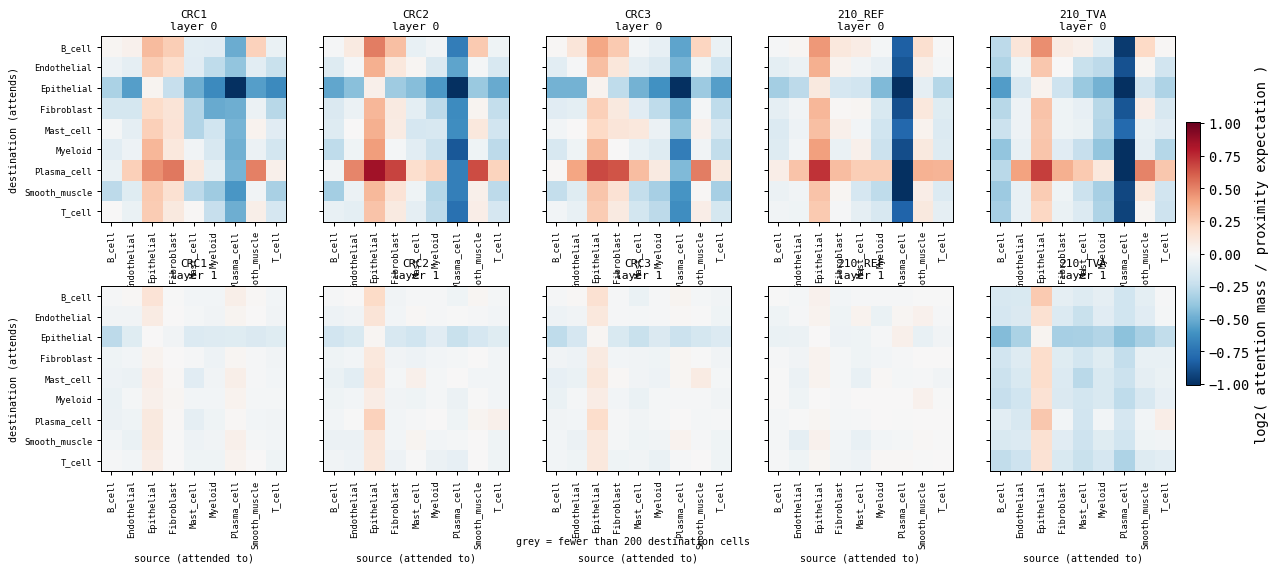

In [13]:
def grid_for(layer):
    out = {}
    for m_name in ME_PRESENT:
        sub = agg[(agg.layer == layer) & (agg.microenvironment == m_name)]
        piv = sub.pivot(index="dst_type", columns="src_type", values="log2_enrichment")
        okp = sub.pivot(index="dst_type", columns="src_type", values="ok")
        piv = piv.reindex(index=CELL_TYPES, columns=CELL_TYPES)
        okp = okp.reindex(index=CELL_TYPES, columns=CELL_TYPES).fillna(False)
        out[m_name] = (piv, okp.astype(bool))
    return out

grids = {l: grid_for(l) for l in att}
allv = np.concatenate([g[m][0].values[g[m][1].values] for g in grids.values() for m in ME_PRESENT])
allv = allv[np.isfinite(allv)]
vmax = float(np.nanpercentile(np.abs(allv), 99)) if allv.size else 1.0
print(f"shared colour scale: +/- {vmax:.2f} log2 (99th pct of |enrichment|)")

fig, axes = plt.subplots(len(att), len(ME_PRESENT),
                         figsize=(3.15 * len(ME_PRESENT), 3.3 * len(att)), squeeze=False)
cmap = plt.get_cmap("RdBu_r").copy()
for r, layer in enumerate(att):
    for c, m_name in enumerate(ME_PRESENT):
        piv, okp = grids[layer][m_name]
        V = np.ma.masked_where(~okp.values | ~np.isfinite(piv.values), piv.values)
        ax = axes[r, c]
        ax.set_facecolor("#d9d9d9")
        im = ax.imshow(V, cmap=cmap, vmin=-vmax, vmax=vmax)
        ax.set_xticks(range(len(CELL_TYPES)))
        ax.set_yticks(range(len(CELL_TYPES)))
        ax.set_xticklabels(CELL_TYPES, rotation=90, fontsize=7)
        ax.set_yticklabels(CELL_TYPES if c == 0 else [], fontsize=7)
        ax.set_title(f"{m_name}\nlayer {layer}", fontsize=9)
        if c == 0:
            ax.set_ylabel("destination (attends)", fontsize=8)
        if r == len(att) - 1:
            ax.set_xlabel("source (attended to)", fontsize=8)
fig.colorbar(im, ax=axes, fraction=0.012, pad=0.01,
             label="log2( attention mass / proximity expectation )")
fig.suptitle("grey = fewer than %d destination cells" % MIN_DST, y=0.02, fontsize=8)
plt.show()

## 9. Which interactions differ between the CRC microenvironments?

Ranked by spread (max - min) of the log2 enrichment across CRC1/CRC2/CRC3, keeping only pairs that clear the `n_dst` threshold in all three.

In [14]:
CRC_MES = [m for m in ["CRC1", "CRC2", "CRC3"] if m in ME_PRESENT]
spread_tables = {}

for layer in att:
    sub = agg[(agg.layer == layer) & agg.microenvironment.isin(CRC_MES) & agg.ok]
    piv = sub.pivot_table(index=["dst_type", "src_type"], columns="microenvironment",
                          values="log2_enrichment")
    piv = piv.dropna(subset=CRC_MES) if all(m in piv.columns for m in CRC_MES) else piv.dropna()
    piv = piv.reindex(columns=CRC_MES)
    piv["spread"] = piv.max(axis=1) - piv.min(axis=1)
    piv = piv.sort_values("spread", ascending=False)
    spread_tables[layer] = piv

    print(f"\n===== layer {layer}: top 15 by across-microenvironment spread =====")
    print(piv.head(15).round(3).to_string())
    print(f"({len(piv)} pairs clear n_dst >= {MIN_DST} in all of {CRC_MES}; "
          f"median spread {piv['spread'].median():.3f})")
    summary[f"max_spread_l{layer}"] = round(float(piv["spread"].max()), 3)
    summary[f"median_spread_l{layer}"] = round(float(piv["spread"].median()), 3)


===== layer 0: top 15 by across-microenvironment spread =====
microenvironment            CRC1   CRC2   CRC3  spread
dst_type      src_type                                
Mast_cell     Mast_cell   -0.294 -0.167  0.106   0.400
Plasma_cell   Epithelial   0.463  0.850  0.666   0.387
Myeloid       Plasma_cell -0.489 -0.858 -0.696   0.369
Plasma_cell   Myeloid     -0.096  0.231  0.087   0.327
T_cell        Plasma_cell -0.491 -0.752 -0.632   0.261
Fibroblast    Myeloid     -0.513 -0.263 -0.259   0.254
Plasma_cell   Endothelial  0.243  0.490  0.395   0.247
              Plasma_cell -0.467 -0.690 -0.443   0.246
Smooth_muscle Mast_cell   -0.265 -0.043 -0.240   0.223
Mast_cell     Plasma_cell -0.470 -0.627 -0.407   0.220
Plasma_cell   Mast_cell    0.107  0.167  0.315   0.208
Epithelial    B_cell      -0.318 -0.526 -0.474   0.208
B_cell        Epithelial   0.322  0.518  0.393   0.196
Fibroblast    Mast_cell   -0.297 -0.102 -0.112   0.196
T_cell        Mast_cell    0.012 -0.089 -0.183   0.195
(8

In [15]:
# strongest enrichments overall (layer 0), for orientation
top = (agg[(agg.layer == 0) & agg.ok]
       .dropna(subset=["log2_enrichment"])
       .assign(absval=lambda d: d.log2_enrichment.abs())
       .sort_values("absval", ascending=False)
       .head(20)[["microenvironment", "dst_type", "src_type", "n_dst",
                  "mass", "expected", "log2_enrichment"]])
print("layer 0 - 20 strongest enrichments (any microenvironment):")
print(top.round(4).to_string(index=False))

layer 0 - 20 strongest enrichments (any microenvironment):
microenvironment      dst_type    src_type  n_dst   mass  expected  log2_enrichment
         210_REF    Epithelial Plasma_cell  20271 0.0253    0.0589          -1.2179
            CRC3    Epithelial Plasma_cell  77177 0.0010    0.0022          -1.2143
            CRC2    Epithelial Plasma_cell  90880 0.0038    0.0087          -1.1922
         210_TVA    Epithelial Plasma_cell 150839 0.0059    0.0133          -1.1696
         210_TVA   Plasma_cell Plasma_cell   7654 0.1767    0.3846          -1.1220
         210_TVA       Myeloid Plasma_cell   7903 0.0347    0.0730          -1.0724
         210_REF   Plasma_cell Plasma_cell   4817 0.2102    0.4410          -1.0691
            CRC1    Epithelial Plasma_cell  37830 0.0004    0.0008          -1.0256
         210_REF Smooth_muscle Plasma_cell   1453 0.0438    0.0885          -1.0157
         210_TVA        B_cell Plasma_cell   3047 0.1132    0.2208          -0.9638
         210_TVA 

## 10. Save

In [16]:
agg.to_csv(f"{RES_DIR}/attention_celltype_enrichment.csv", index=False)
for layer, piv in spread_tables.items():
    piv.round(4).to_csv(f"{RES_DIR}/attention_spread_ranked_l{layer}.csv")

summary["cell_types"] = CELL_TYPES
summary["microenvironments"] = ME_PRESENT
summary["min_dst"] = MIN_DST
with open(f"{RES_DIR}/attention_summary.json", "w") as fh:
    json.dump(summary, fh, indent=2, default=str)

print(json.dumps(summary, indent=2, default=str))
print("\nwritten to", RES_DIR)
for f in sorted(os.listdir(RES_DIR)):
    if f.startswith("attention"):
        print(f"  {f}  {os.path.getsize(RES_DIR + '/' + f)/1e6:.1f} MB")

{
  "n_cells": 552241,
  "n_genes": 2000,
  "out_degree_max": 20,
  "in_degree_max": 39,
  "n_zero_in_degree": 20,
  "graph_symmetric": false,
  "extract_minutes": 0.3,
  "extract_peak_vram_gb": 0.09,
  "attention_nnz": {
    "0": 11044820,
    "1": 11044820
  },
  "entropy_ratio_median_l0": 0.9041,
  "uniform_like_l0": false,
  "entropy_ratio_median_l1": 0.9886,
  "uniform_like_l1": true,
  "edge_dist_median": 123.32,
  "boundary_edge_pct": {
    "CRC1": 45.2,
    "CRC2": 39.4,
    "CRC3": 59.1,
    "210_REF": 1.1,
    "210_TVA": 0.4
  },
  "max_spread_l0": 0.4,
  "median_spread_l0": 0.087,
  "max_spread_l1": 0.162,
  "median_spread_l1": 0.033,
  "cell_types": [
    "B_cell",
    "Endothelial",
    "Epithelial",
    "Fibroblast",
    "Mast_cell",
    "Myeloid",
    "Plasma_cell",
    "Smooth_muscle",
    "T_cell"
  ],
  "microenvironments": [
    "CRC1",
    "CRC2",
    "CRC3",
    "210_REF",
    "210_TVA"
  ],
  "min_dst": 200
}

written to ../results/analysis/crc_210_gat
  attention